In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

In [3]:
# Load master dataset
import os
relationship_path = '../data/relationship/'
master_df = pd.read_csv(os.path.join(relationship_path, 'master_relationship_table.csv'))

print("="*60)
print("MASTER DATASET LOADED")
print("="*60)
print(f"Shape: {master_df.shape}")
print(f"Years: {master_df['Year'].unique().tolist()}")
print(f"Categories: {master_df['Category'].unique().tolist()}")
print(f"Columns: {master_df.columns.tolist()}")
print(master_df.head())

MASTER DATASET LOADED
Shape: (288, 15)
Years: [2020, 2021, 2022, 2023, 2024, 2025]
Categories: ['Alcoholic drinks', 'Audio-visual equipment', 'Beef', 'Bread, rice and cereals', 'Buns, cakes, biscuits', 'Cleaning materials', 'Clothing', 'Combined telecom', 'Electricity', 'Fish', 'Food', 'Footwear', 'Fruit', 'Furniture and furnishings', 'Gas', 'Hospital services', 'Hotel accommodation', 'Household appliances', 'Household hardware', 'Household textiles', 'Housing (net)', 'Insurance', 'Internet', 'Maintenance and repair', 'Medical products', 'Milk and dairy', 'Newspapers and books', 'Non-alcoholic drinks', 'Other food', 'Other fuels', 'Other services', 'Package holidays', 'Personal care', 'Petrol, diesel and oils', 'Pets and pet food', 'Poultry', 'Public transport', 'Restaurant meals', 'Sports and recreation', 'Sugar and confectionery', 'TV subscriptions', 'Take-away food', 'Telephone services', 'Tobacco', 'Vegetables', 'Vehicle purchase', 'Vehicle repairs', 'Water supply']
Columns: ['Year

## UNIVARIATE ANALYSIS


What are the typical spending patterns and price ranges?


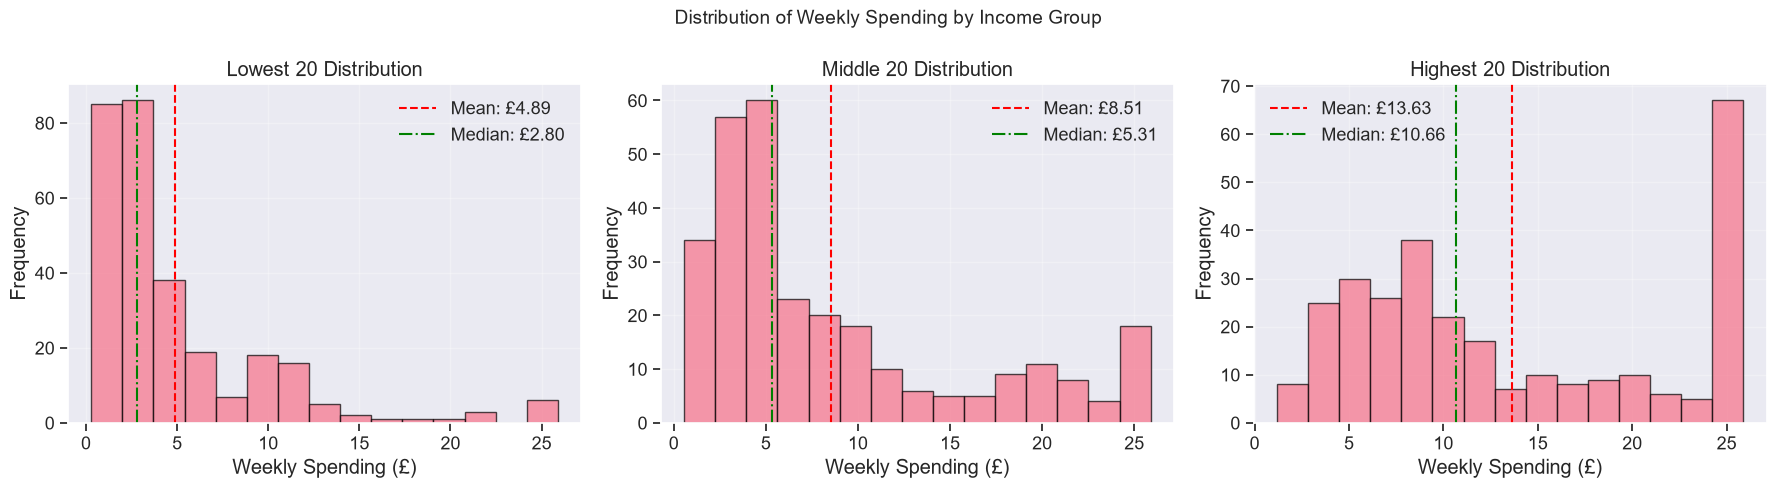


----------------------------------------
Spending Summary Statistics:
----------------------------------------
       Spending_Lowest_20  Spending_Middle_20  Spending_Highest_20
count          288.000000          288.000000           288.000000
mean             4.886536            8.511892            13.627422
std              5.043851            7.195757             8.289472
min              0.290000            0.560000             1.180000
25%              1.807500            3.447500             6.867500
50%              2.805000            5.315000            10.665000
75%              5.967500           11.185000            22.555000
max             25.892500           25.892500            25.892500


In [5]:
print("\n" + "="*60)
print("What are the typical spending patterns and price ranges?")
print("="*60)


# Distribution of Spending by Income Group
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

spending_cols = ['Spending_Lowest_20', 'Spending_Middle_20', 'Spending_Highest_20']

for idx, col in enumerate(spending_cols):
    ax = axes[idx]
    # Histogram
    ax.hist(master_df[col].dropna(), bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(master_df[col].mean(), color='red', linestyle='--', label=f'Mean: £{master_df[col].mean():.2f}')
    ax.axvline(master_df[col].median(), color='green', linestyle='-.', label=f'Median: £{master_df[col].median():.2f}')
    ax.set_xlabel('Weekly Spending (£)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col.replace("Spending_", "").replace("_", " ")} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Weekly Spending by Income Group', fontsize=14)
plt.tight_layout()
plt.savefig('../data/relationship/eda_univariate_spending_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary Statistics
print("\n" + "-"*40)
print("Spending Summary Statistics:")
print("-"*40)
spending_stats = master_df[spending_cols].describe()
print(spending_stats)

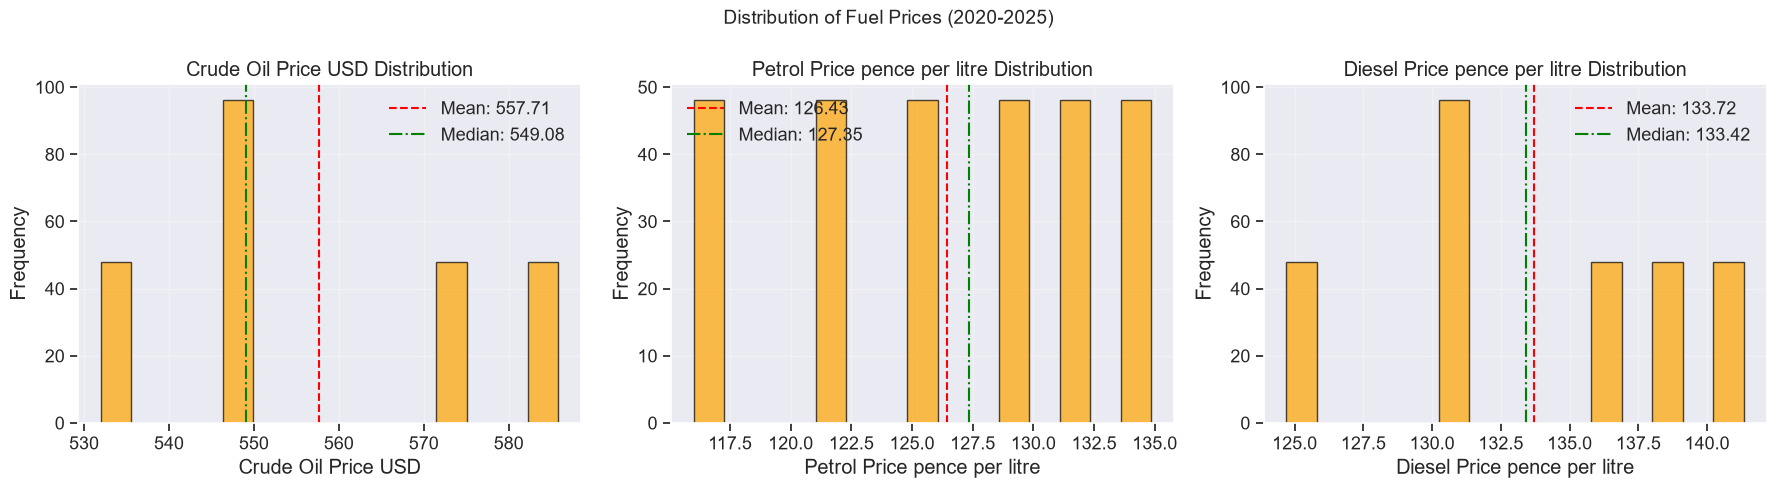


----------------------------------------
Fuel Price Summary Statistics:
----------------------------------------
       Crude_Oil_Price_USD  Petrol_Price_pence_per_litre  \
count           240.000000                    288.000000   
mean            557.709607                    126.427766   
std              19.275156                      6.336237   
min             531.979072                    116.000000   
25%             548.526875                    121.320548   
50%             549.077525                    127.352055   
75%             573.121327                    131.692623   
max             585.843235                    134.849315   

       Diesel_Price_pence_per_litre  
count                    288.000000  
mean                     133.721317  
std                        5.584683  
min                      124.700000  
25%                      130.772329  
50%                      133.415046  
75%                      138.686301  
max                      141.339178  


In [6]:
# Distribution of Fuel Prices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

price_cols = ['Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 'Diesel_Price_pence_per_litre']

for idx, col in enumerate(price_cols):
    ax = axes[idx]
    ax.hist(master_df[col].dropna(), bins=15, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(master_df[col].mean(), color='red', linestyle='--', label=f'Mean: {master_df[col].mean():.2f}')
    ax.axvline(master_df[col].median(), color='green', linestyle='-.', label=f'Median: {master_df[col].median():.2f}')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col.replace("_", " ")} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Fuel Prices (2020-2025)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/relationship/eda_univariate_fuel_prices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "-"*40)
print("Fuel Price Summary Statistics:")
print("-"*40)
price_stats = master_df[price_cols].describe()
print(price_stats)

# BIVARIATE ANALYSIS


How do fuel price changes relate to household spending patterns?

Actual categories in dataset:
['Alcoholic drinks' 'Audio-visual equipment' 'Beef'
 'Bread, rice and cereals' 'Buns, cakes, biscuits' 'Cleaning materials'
 'Clothing' 'Combined telecom' 'Electricity' 'Fish' 'Food' 'Footwear'
 'Fruit' 'Furniture and furnishings' 'Gas' 'Hospital services'
 'Hotel accommodation' 'Household appliances' 'Household hardware'
 'Household textiles' 'Housing (net)' 'Insurance' 'Internet'
 'Maintenance and repair' 'Medical products' 'Milk and dairy'
 'Newspapers and books' 'Non-alcoholic drinks' 'Other food' 'Other fuels'
 'Other services' 'Package holidays' 'Personal care'
 'Petrol, diesel and oils' 'Pets and pet food' 'Poultry'
 'Public transport' 'Restaurant meals' 'Sports and recreation'
 'Sugar and confectionery' 'TV subscriptions' 'Take-away food'
 'Telephone services' 'Tobacco' 'Vegetables' 'Vehicle purchase'
 'Vehicle repairs' 'Water supply']

Food - Lowest 20%: 5 valid points
Food - Middl

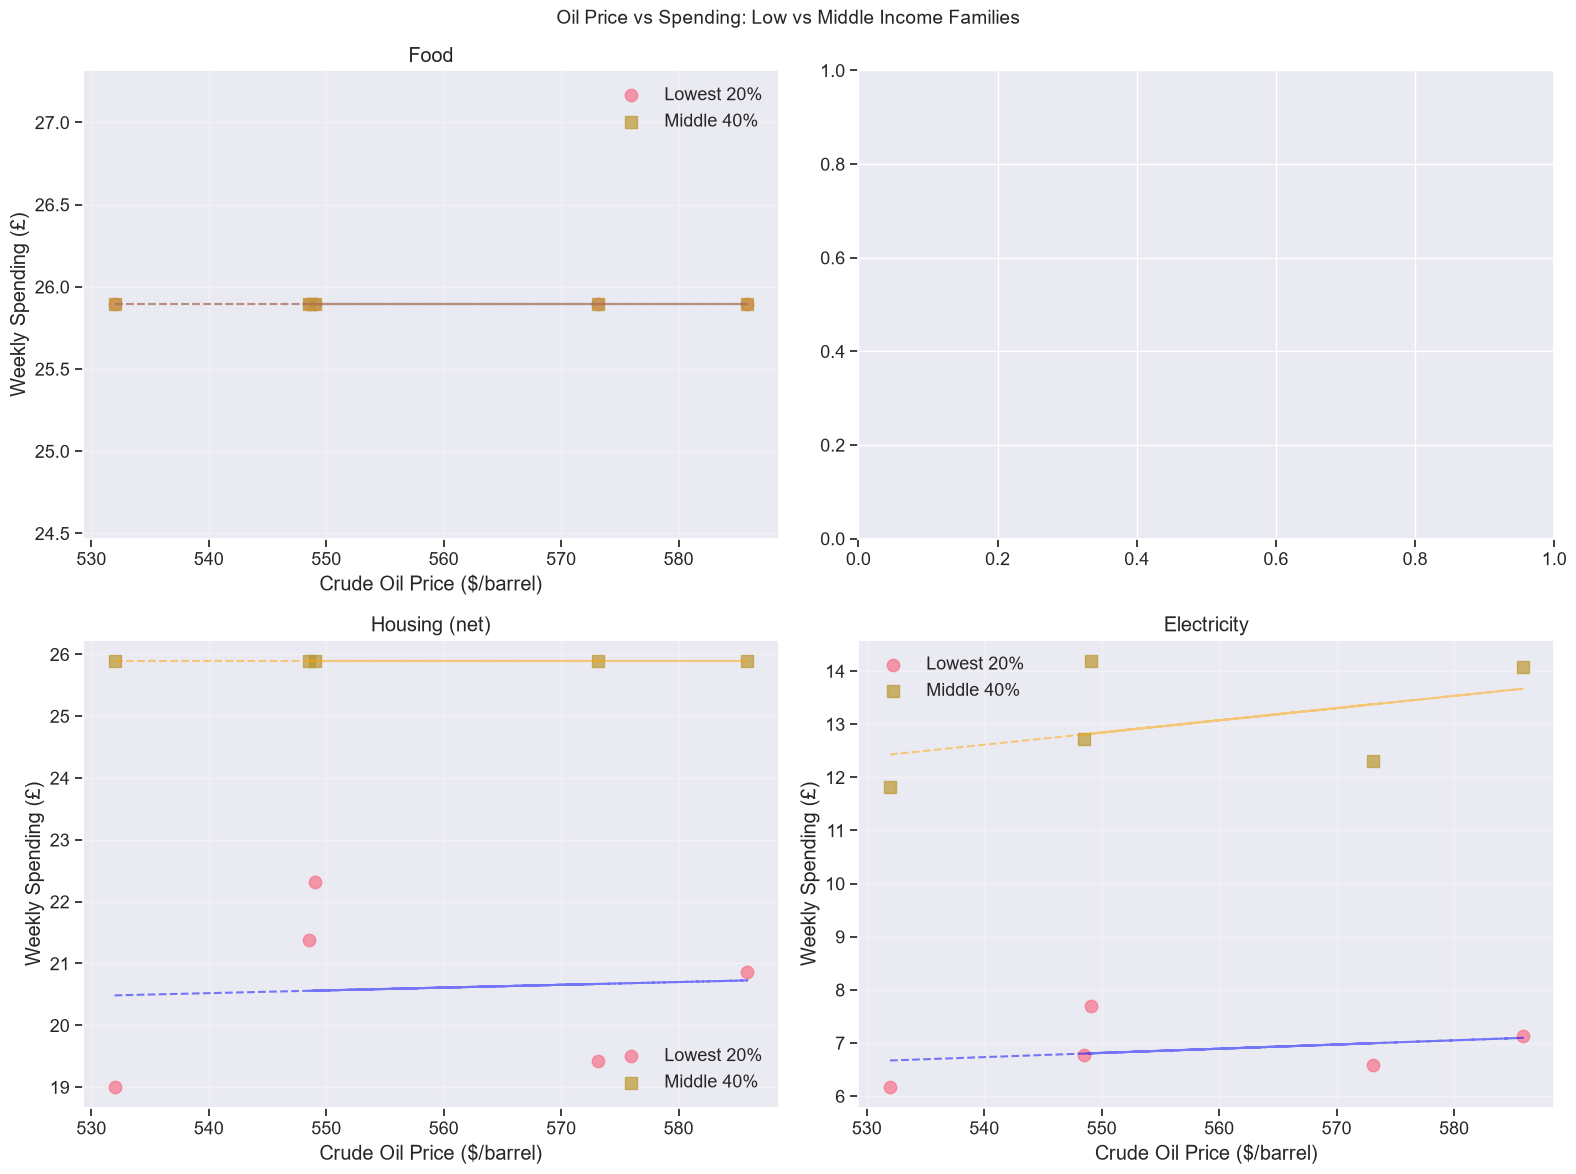

In [18]:
print("\n" + "="*60)
print("How do fuel price changes relate to household spending patterns?")
print("="*60)

# Check actual category names first
print("\nActual categories in dataset:")
print(master_df['Category'].unique())

# Oil Price vs Spending by Category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Use exact category names from your dataset
plot_categories = ['Food', 'Transport', 'Housing (net)', 'Electricity']

for idx, category in enumerate(plot_categories[:4]):
    ax = axes[idx]
    cat_data = master_df[master_df['Category'] == category]
    
    if len(cat_data) > 0:
        ax.scatter(cat_data['Crude_Oil_Price_USD'], cat_data['Spending_Lowest_20'], 
                  label='Lowest 20%', s=80, alpha=0.7, marker='o')
        ax.scatter(cat_data['Crude_Oil_Price_USD'], cat_data['Spending_Middle_20'], 
                  label='Middle 40%', s=80, alpha=0.7, marker='s')
        
        # Add trend lines
        valid_idx = cat_data['Crude_Oil_Price_USD'].notna() & cat_data['Spending_Lowest_20'].notna()
        x_valid = cat_data.loc[valid_idx, 'Crude_Oil_Price_USD']
        y_valid = cat_data.loc[valid_idx, 'Spending_Lowest_20']
        print(f"\n{category} - Lowest 20%: {len(x_valid)} valid points")
        if len(x_valid) > 1:
            z1 = np.polyfit(x_valid, y_valid, 1)
            p1 = np.poly1d(z1)
            ax.plot(x_valid, p1(x_valid), '--', alpha=0.5, color='blue')
        
        valid_idx2 = cat_data['Crude_Oil_Price_USD'].notna() & cat_data['Spending_Middle_20'].notna()
        x_valid2 = cat_data.loc[valid_idx2, 'Crude_Oil_Price_USD']
        y_valid2 = cat_data.loc[valid_idx2, 'Spending_Middle_20']
        print(f"{category} - Middle 40%: {len(x_valid2)} valid points")
        if len(x_valid2) > 1:
            z2 = np.polyfit(x_valid2, y_valid2, 1)
            p2 = np.poly1d(z2)
            ax.plot(x_valid2, p2(x_valid2), '--', alpha=0.5, color='orange')
        
        ax.set_xlabel('Crude Oil Price ($/barrel)')
        ax.set_ylabel('Weekly Spending (£)')
        ax.set_title(f'{category}')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Oil Price vs Spending: Low vs Middle Income Families', fontsize=14)
plt.tight_layout()
plt.savefig('../data/relationship/eda_bivariate_oil_vs_spending.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
print(master_df.columns.tolist())


['Year', 'Category', 'Spending_Lowest_20', 'Spending_Second_20', 'Spending_Middle_20', 'Spending_Fourth_20', 'Spending_Highest_20', 'Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 'Diesel_Price_pence_per_litre', 'CPI_Fuels_and_Lubricants', 'CPI_Electricity', 'CPI_Gas', 'CPI_Liquid_Fuels', 'CPI_Solid_Fuels', 'Spending_Gap_Low_Middle']


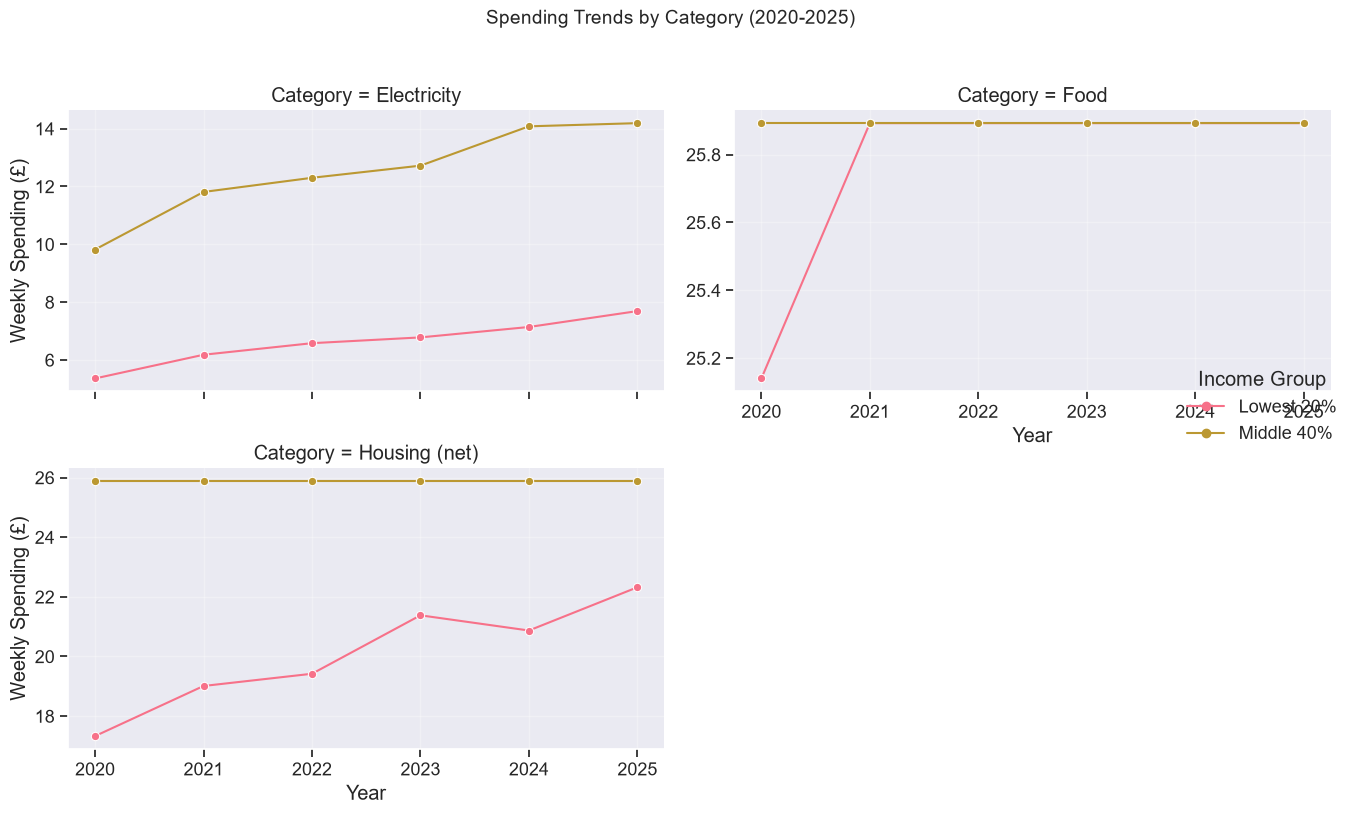

In [ ]:

# List the specific categories you want to plot
target_categories = ['Food', 'Housing (net)', 'Electricity']

# Filter the dataframe to just those categories
filtered_df = master_df[master_df['Category'].isin(target_categories)]

# Melt the dataframe using your ACTUAL column names
tidy_df = filtered_df.melt(
    id_vars=['Year', 'Category'], 
    value_vars=['Spending_Lowest_20', 'Spending_Middle_20'],  # Exact match from your printout
    var_name='Income_Group_Code', 
    value_name='Weekly Spending (£)'
)

# Clean up the legend labels 
label_mapping = {
    'Spending_Lowest_20': 'Lowest 20%',
    'Spending_Middle_20': 'Middle 40%'
}
tidy_df['Income Group'] = tidy_df['Income_Group_Code'].map(label_mapping)

# Plot using Seaborn FacetGrid
g = sns.relplot(
    data=tidy_df, 
    x='Year', 
    y='Weekly Spending (£)', 
    hue='Income Group',  
    col='Category', 
    col_wrap=2,          
    kind='line', 
    marker='o',
    height=4, 
    aspect=1.5,
    facet_kws={'sharey': False} 
)

# Formatting
g.fig.suptitle('Spending Trends by Category (2020-2025)', y=1.02, fontsize=14)
for ax in g.axes.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/relationship/eda_bivariate_spending_trends.png', dpi=300, bbox_inches='tight')
plt.show()

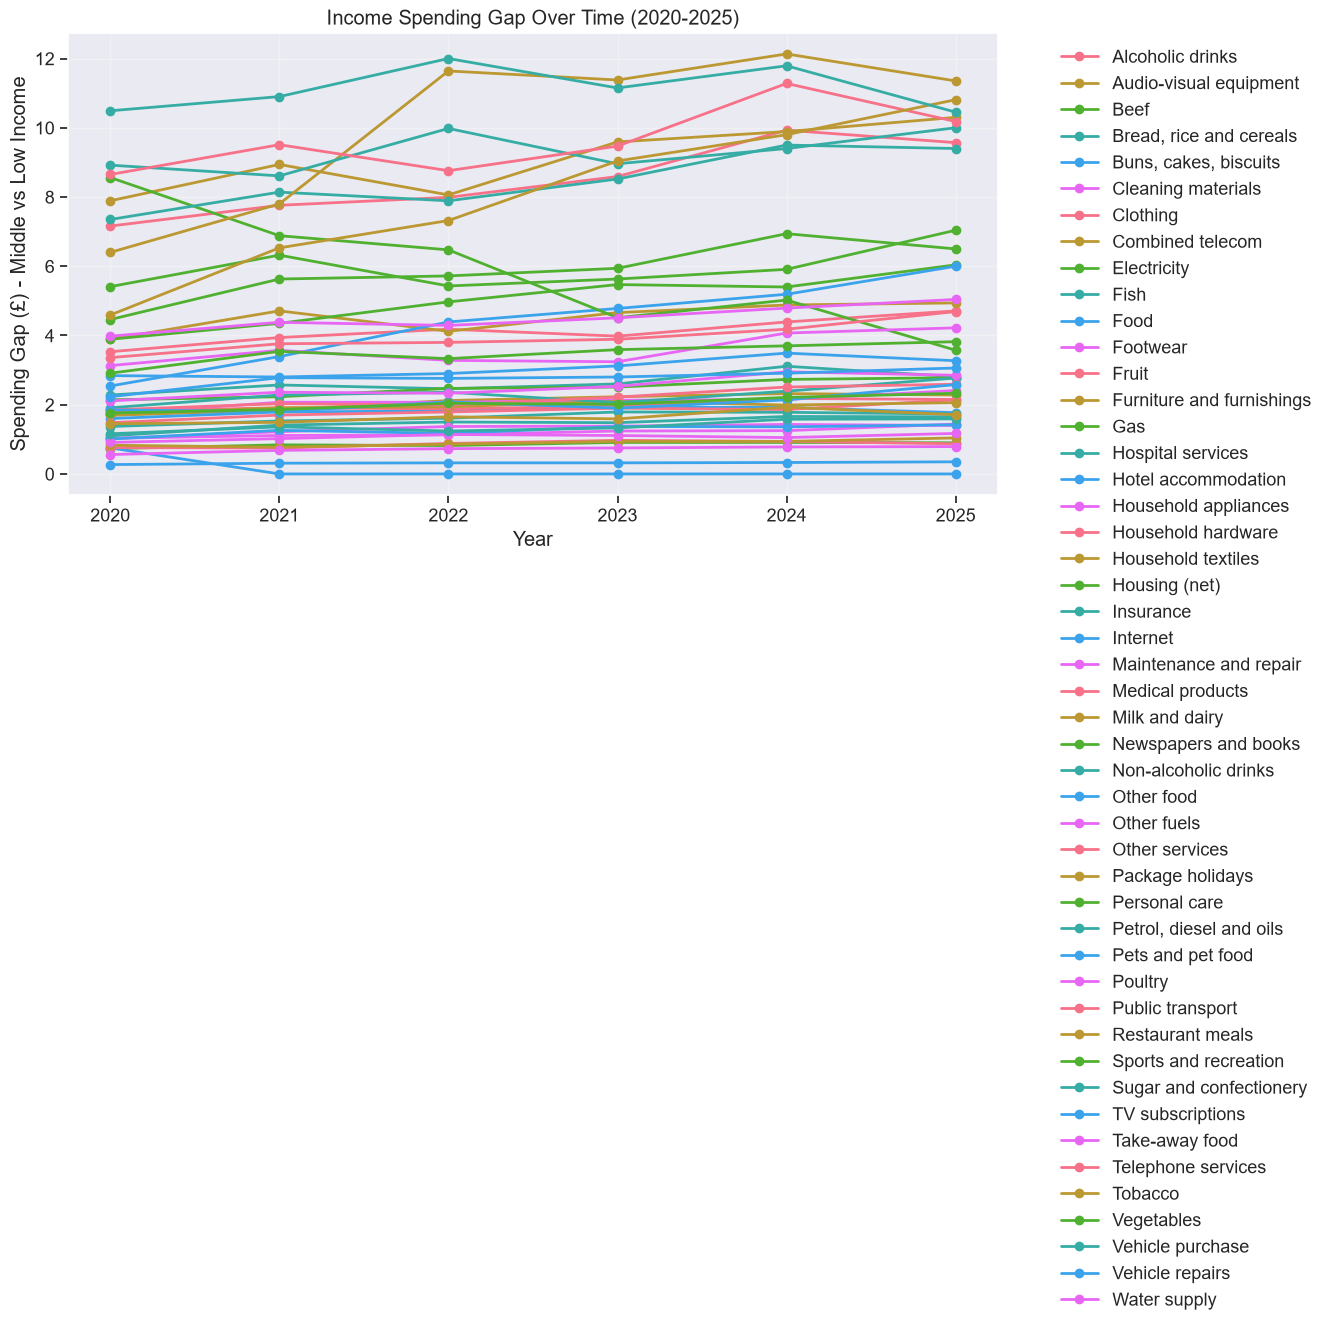

In [9]:
# Fuel Price vs Spending Gap
master_df['Spending_Gap_Low_Middle'] = master_df['Spending_Middle_20'] - master_df['Spending_Lowest_20']

fig, ax = plt.subplots(figsize=(12, 6))

# Plot gap over time
for category in master_df['Category'].unique():
    cat_data = master_df[master_df['Category'] == category]
    if len(cat_data) > 0:
        ax.plot(cat_data['Year'], cat_data['Spending_Gap_Low_Middle'], 
               marker='o', label=category, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Spending Gap (£) - Middle vs Low Income')
ax.set_title('Income Spending Gap Over Time (2020-2025)')
ax.legend(bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/relationship/eda_bivariate_spending_gap.png', dpi=300, bbox_inches='tight')
plt.show()


----------------------------------------
Correlation Matrix - Key Variables
----------------------------------------


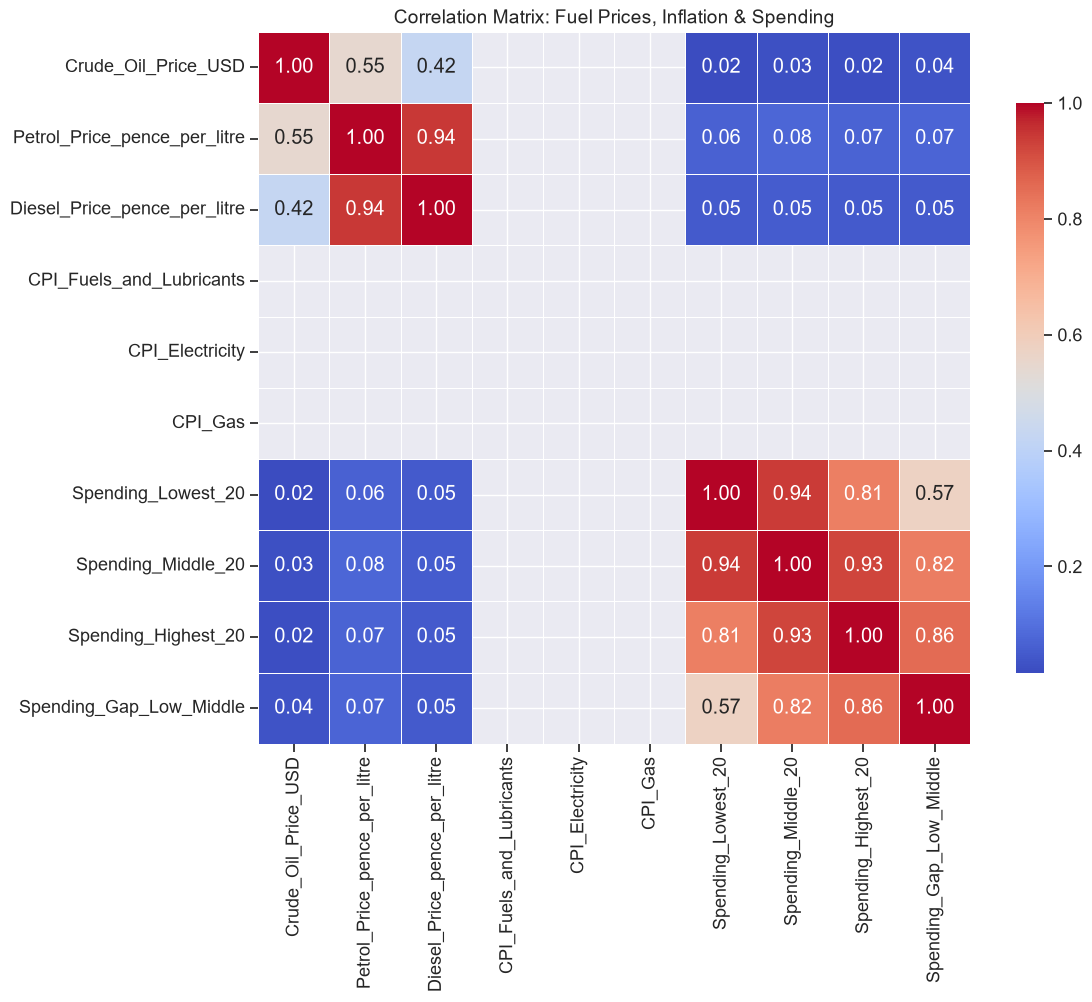

In [10]:
# Correlation Heatmap
print("\n" + "-"*40)
print("Correlation Matrix - Key Variables")
print("-"*40)

# Select key numeric columns
corr_cols = ['Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 'Diesel_Price_pence_per_litre',
             'CPI_Fuels_and_Lubricants', 'CPI_Electricity', 'CPI_Gas',
             'Spending_Lowest_20', 'Spending_Middle_20', 'Spending_Highest_20',
             'Spending_Gap_Low_Middle']

# Filter columns that exist
corr_cols_exist = [col for col in corr_cols if col in master_df.columns]

corr_matrix = master_df[corr_cols_exist].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Fuel Prices, Inflation & Spending', fontsize=14)
plt.tight_layout()
plt.savefig('../data/relationship/eda_multivariate_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# # MULTIVARIATE ANALYSIS


What combination of factors best explains spending behavior differences?


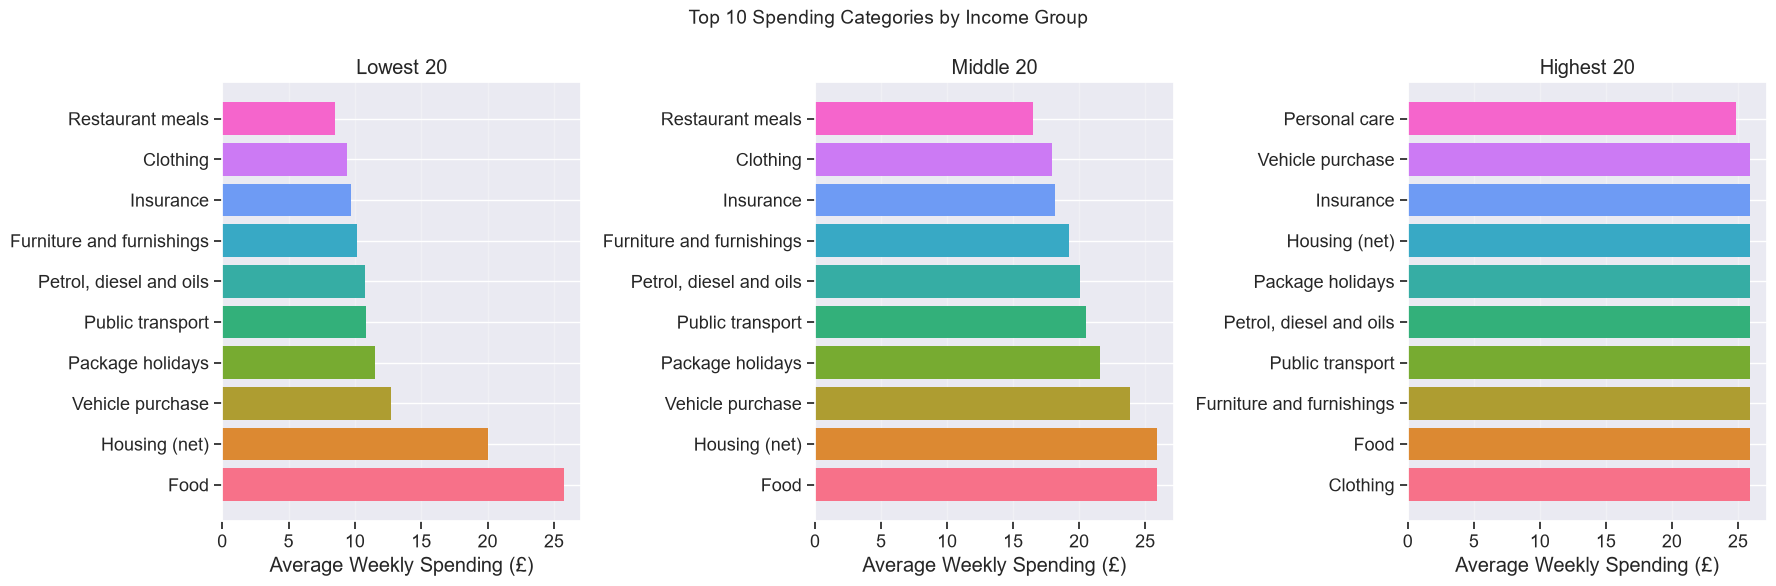

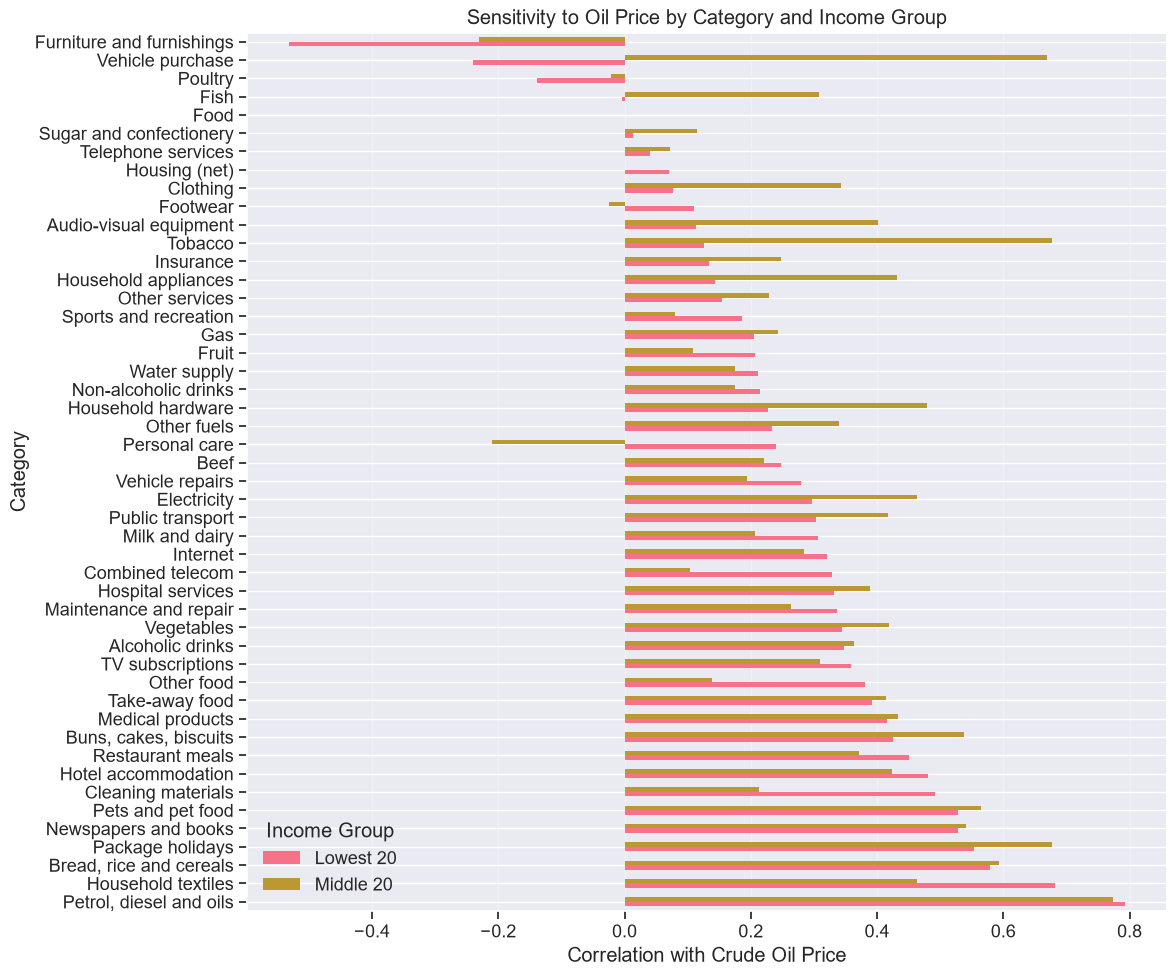

In [11]:

print("\n" + "="*60)
print("What combination of factors best explains spending behavior differences?")
print("="*60)

# Spending Composition by Income Group
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

income_groups = ['Spending_Lowest_20', 'Spending_Middle_20', 'Spending_Highest_20']

for idx, income_col in enumerate(income_groups):
    ax = axes[idx]
    # Calculate average spending by category for this income group
    avg_spending = master_df.groupby('Category')[income_col].mean().sort_values(ascending=False)
    
    ax.barh(avg_spending.index[:10], avg_spending.values[:10], color=sns.color_palette("husl", 10))
    ax.set_xlabel('Average Weekly Spending (£)')
    ax.set_title(f'{income_col.replace("Spending_", "").replace("_", " ")}')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Top 10 Spending Categories by Income Group', fontsize=14)
plt.tight_layout()
plt.savefig('../data/relationship/eda_multivariate_spending_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Fuel Price Impact on Different Categories
fig, ax = plt.subplots(figsize=(14, 8))

# Calculate correlation between oil price and spending for each category
correlations = []
for category in master_df['Category'].unique():
    cat_data = master_df[master_df['Category'] == category]
    if len(cat_data) > 1:
        for income in ['Spending_Lowest_20', 'Spending_Middle_20']:
            corr = cat_data['Crude_Oil_Price_USD'].corr(cat_data[income])
            correlations.append({
                'Category': category,
                'Income_Group': income.replace('Spending_', '').replace('_', ' '),
                'Correlation': corr
            })

corr_df = pd.DataFrame(correlations)
corr_pivot = corr_df.pivot(index='Category', columns='Income_Group', values='Correlation').sort_values('Lowest 20', ascending=False)

# Plot
corr_pivot.plot(kind='barh', ax=ax, figsize=(12, 10))
ax.set_xlabel('Correlation with Crude Oil Price')
ax.set_title('Sensitivity to Oil Price by Category and Income Group')
ax.legend(title='Income Group')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/relationship/eda_multivariate_category_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# FEATURE-TARGET ANALYSIS (Statistical Tests)

In [12]:
print("\n" + "="*60)
print("Business Question: Which factors are statistically significant in explaining spending differences?")
print("="*60)


Business Question: Which factors are statistically significant in explaining spending differences?


In [13]:
# T-Test: Low vs Middle Income Spending
print("\n" + "-"*40)
print("T-Test: Low vs Middle Income Spending")
print("-"*40)

test_results = []

for category in master_df['Category'].unique():
    cat_data = master_df[master_df['Category'] == category]
    
    if len(cat_data) > 0:
        # T-test
        t_stat, p_value = stats.ttest_ind(
            cat_data['Spending_Lowest_20'].dropna(), 
            cat_data['Spending_Middle_20'].dropna()
        )
        
        # Calculate means
        mean_low = cat_data['Spending_Lowest_20'].mean()
        mean_middle = cat_data['Spending_Middle_20'].mean()
        
        test_results.append({
            'Category': category,
            'Mean_Low': mean_low,
            'Mean_Middle': mean_middle,
            'Difference': mean_middle - mean_low,
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Significant': p_value < 0.05
        })

test_df = pd.DataFrame(test_results)
test_df = test_df.sort_values('Difference', ascending=False)

print(test_df)


----------------------------------------
T-Test: Low vs Middle Income Spending
----------------------------------------
                     Category   Mean_Low  Mean_Middle  Difference  \
45           Vehicle purchase  12.738333    23.868333   11.130000   
31           Package holidays  11.488333    21.605833   10.117500   
36           Public transport  10.866667    20.508333    9.641667   
33    Petrol, diesel and oils  10.745000    20.056667    9.311667   
13  Furniture and furnishings  10.121667    19.233333    9.111667   
6                    Clothing   9.431667    17.931667    8.500000   
21                  Insurance   9.728333    18.195000    8.466667   
37           Restaurant meals   8.496667    16.511667    8.015000   
32              Personal care   6.778333    12.735000    5.956667   
8                 Electricity   6.621667    12.486667    5.865000   
20              Housing (net)  20.055000    25.892500    5.837500   
14                        Gas   5.503333    10.5233

In [14]:
# Correlation Significance Test
print("\n" + "-"*40)
print("Correlation Significance: Oil Price vs Spending")
print("-"*40)

corr_significance = []

for category in master_df['Category'].unique():
    cat_data = master_df[master_df['Category'] == category]
    
    if len(cat_data) > 2:
        for income in ['Spending_Lowest_20', 'Spending_Middle_20']:
            # Remove NaN
            clean_data = cat_data[['Crude_Oil_Price_USD', income]].dropna()
            
            if len(clean_data) > 2:
                corr, p_value = pearsonr(clean_data['Crude_Oil_Price_USD'], clean_data[income])
                
                corr_significance.append({
                    'Category': category,
                    'Income_Group': income.replace('Spending_', '').replace('_', ' '),
                    'Correlation': corr,
                    'P_Value': p_value,
                    'Significant': p_value < 0.05
                })

corr_sig_df = pd.DataFrame(corr_significance)
print(corr_sig_df)


----------------------------------------
Correlation Significance: Oil Price vs Spending
----------------------------------------
                  Category Income_Group  Correlation   P_Value  Significant
0         Alcoholic drinks    Lowest 20     0.347703  0.566381        False
1         Alcoholic drinks    Middle 20     0.362934  0.548253        False
2   Audio-visual equipment    Lowest 20     0.113171  0.856214        False
3   Audio-visual equipment    Middle 20     0.400811  0.503686        False
4                     Beef    Lowest 20     0.248046  0.687448        False
..                     ...          ...          ...       ...          ...
91        Vehicle purchase    Middle 20     0.668727  0.217149        False
92         Vehicle repairs    Lowest 20     0.279496  0.648823        False
93         Vehicle repairs    Middle 20     0.193754  0.754857        False
94            Water supply    Lowest 20     0.211432  0.732816        False
95            Water supply    Mid

In [15]:
# ANOVA: Spending Differences Across Income Groups

print("\n" + "-"*40)
print("ANOVA: Spending Differences Across Income Groups")
print("-"*40)

anova_results = []

for category in master_df['Category'].unique():
    cat_data = master_df[master_df['Category'] == category]
    
    if len(cat_data) > 0:
        # Prepare groups
        groups = []
        for income in ['Spending_Lowest_20', 'Spending_Middle_20', 'Spending_Highest_20']:
            if income in cat_data.columns:
                groups.append(cat_data[income].dropna())
        
        if len(groups) >= 2:
            f_stat, p_value = f_oneway(*groups)
            
            anova_results.append({
                'Category': category,
                'F_Statistic': f_stat,
                'P_Value': p_value,
                'Significant': p_value < 0.05
            })

anova_df = pd.DataFrame(anova_results)
print(anova_df)



----------------------------------------
ANOVA: Spending Differences Across Income Groups
----------------------------------------
                     Category  F_Statistic       P_Value  Significant
0            Alcoholic drinks   209.947697  1.078446e-11         True
1      Audio-visual equipment   166.335200  5.779983e-11         True
2                        Beef   177.239593  3.662348e-11         True
3     Bread, rice and cereals   240.496679  4.023606e-12         True
4       Buns, cakes, biscuits   197.514831  1.677142e-11         True
5          Cleaning materials   221.527597  7.308039e-12         True
6                    Clothing   243.312214  3.696957e-12         True
7            Combined telecom   263.667456  2.059101e-12         True
8                 Electricity   186.779014  2.510529e-11         True
9                        Fish   157.695165  8.471874e-11         True
10                       Food     1.000000  3.911268e-01        False
11                   Footwea